# Development pseudo-OOS: M0–M2

Compare zero-change persistence (M0), the historical mean change (M1), and past-only z-score mean reversion (M2) for the two pre-specified five-SPX-session targets. This notebook uses **2023–2024 only**. Each origin is forecast using labels that matured by that date; the 2025 confirmation period remains locked. Five-session outcomes overlap, so these descriptive scores are not iid significance tests.

## Load the QC-approved development series

The existing pipeline masks invalid surface metrics, inserts every SPX session, constructs exact five-session endpoints, and computes z-scores from at least 60 earlier valid states. We discard 2025 metric rows before building the modelling dataset. The final five development labels are unavailable because their endpoints fall outside 2024.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.forecasting import (
    DEV_END, build_development_dataset, forecast_development,
    score_development_forecasts,
)
from src.time_series import load_skew_metrics

metrics = load_skew_metrics(project_root / 'data/processed/spx_skew_metrics_2023_2025.csv')
metrics = metrics.loc[metrics['quote_date'] <= DEV_END].copy()
spx_prices = pd.read_csv(project_root / 'data/raw/spx_security_prices.csv')
development = build_development_dataset(metrics, spx_prices)
display(pd.Series({
    'development sessions': len(development),
    'first session': development['quote_date'].min().date(),
    'last session': development['quote_date'].max().date(),
    'final five labels unavailable': development[[
        'y_skew_30_5d', 'y_skew_spread_5d'
    ]].tail(5).isna().all().all(),
}))

development sessions                    502
first session                    2023-01-03
last session                     2024-12-31
final five labels unavailable          True
dtype: object

## Compare forecasts on common realised dates

The first origin follows 252 prior SPX sessions. M1 uses only matured labels; M2 fits OLS on the same causal z-score definition used at the forecast origin. For each target, the table scores all three models on identical dates with a valid realised target and all three forecasts. $R^2_{\mathrm{OOS,persist}}=1-\mathrm{SSE}_{\mathrm{model}}/\mathrm{SSE}_{M0}$. Directional accuracy and correlation are undefined for the constant-zero M0 forecast.

In [2]:
targets = {
    '30D skew change': 'y_skew_30_5d',
    '30D–60D spread change': 'y_skew_spread_5d',
}
predictions = {name: forecast_development(development, spx_prices, target)
               for name, target in targets.items()}
scored = {name: score_development_forecasts(frame)
          for name, frame in predictions.items()}
coverage = pd.DataFrame([
    {'target': name, 'origins': len(frame),
     'realised_origins': int(frame['actual'].notna().sum()),
     'common_scored': len(scored[name][1]),
     'first_scored': scored[name][1]['quote_date'].min().date(),
     'last_scored': scored[name][1]['quote_date'].max().date()}
    for name, frame in predictions.items()
])
display(coverage)
summary = pd.concat(
    {name: scored[name][0] for name in targets}, names=['target']
).reset_index(level=0)
numeric_columns = summary.select_dtypes(include='number').columns
summary[numeric_columns] = summary[numeric_columns].round(4)
display(summary)

,target,origins,realised_origins,common_scored,first_scored,last_scored
0,30D skew change,250,245,245,2024-01-04,2024-12-23
1,30D–60D spread change,250,245,245,2024-01-04,2024-12-23


,target,model,n_common,first_date,last_date,rmse,mae,r2_vs_persistence,correlation,directional_accuracy
0,30D skew change,m0_persistence,245,2024-01-04,2024-12-23,0.1180,0.0858,0.0000,NaN,NaN
1,30D skew change,m1_mean,245,2024-01-04,2024-12-23,0.1185,0.0860,-0.0084,-0.5046,0.5510
2,30D skew change,m2_mean_reversion,245,2024-01-04,2024-12-23,0.1067,0.0771,0.1825,0.4490,0.6245
0,30D–60D spread change,m0_persistence,245,2024-01-04,2024-12-23,0.0658,0.0477,0.0000,NaN,NaN
1,30D–60D spread change,m1_mean,245,2024-01-04,2024-12-23,0.0661,0.0479,-0.0083,-0.5223,0.4898
2,30D–60D spread change,m2_mean_reversion,245,2024-01-04,2024-12-23,0.0562,0.0415,0.2703,0.5442,0.6653


## Does improvement accumulate?

Plot cumulative squared-error improvement over M0 on the same scored dates. A sustained upward path is more persuasive than a final gain driven by one short episode; a downward path means the model is worse than persistence.

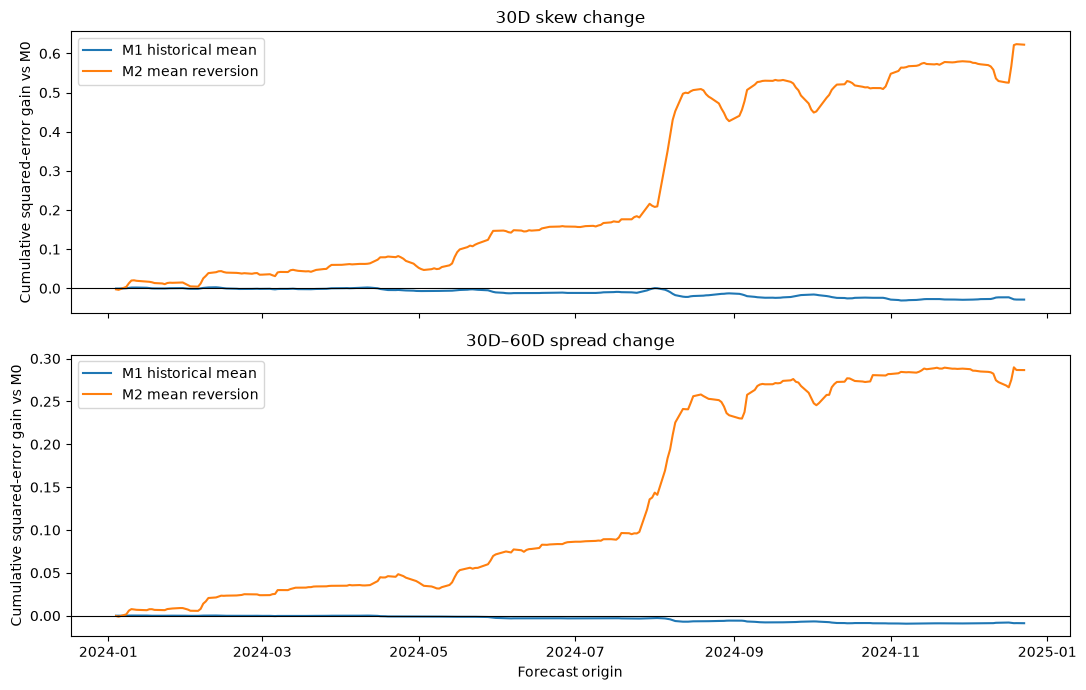

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, (name, (_, common)) in zip(axes, scored.items()):
    actual = common['actual']
    baseline_error = (actual - common['m0_persistence']) ** 2
    for model, label in [('m1_mean', 'M1 historical mean'),
                         ('m2_mean_reversion', 'M2 mean reversion')]:
        gain = baseline_error - (actual - common[model]) ** 2
        ax.plot(common['quote_date'], gain.cumsum(), label=label)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(name)
    ax.set_ylabel('Cumulative squared-error gain vs M0')
    ax.legend()
axes[-1].set_xlabel('Forecast origin')
fig.tight_layout()
plt.show()

## Five non-overlapping origin offsets

For each offset of the five-session horizon, compare RMSE using `session_index % 5`. Missing forecasts do not renumber sessions. These smaller slices are a pre-specified robustness check, not five independent experiments or a basis for selecting the best offset.

In [4]:
offset_rows = []
for name, (_, common) in scored.items():
    for offset in range(5):
        subset = common.loc[common['session_index'].mod(5).eq(offset)]
        row = {'target': name, 'offset': offset, 'n': len(subset)}
        for model in ('m0_persistence', 'm1_mean', 'm2_mean_reversion'):
            row[model] = np.sqrt(np.mean((subset['actual'] - subset[model]) ** 2))
        offset_rows.append(row)
display(pd.DataFrame(offset_rows).round(4))

,target,offset,n,m0_persistence,m1_mean,m2_mean_reversion
0,30D skew change,0,49,0.1108,0.1113,0.1012
1,30D skew change,1,49,0.1073,0.1078,0.0975
2,30D skew change,2,49,0.0968,0.0974,0.0901
3,30D skew change,3,49,0.1524,0.1529,0.1347
4,30D skew change,4,49,0.1150,0.1153,0.1045
5,30D–60D spread change,0,49,0.0576,0.0579,0.0508
6,30D–60D spread change,1,49,0.0673,0.0676,0.0568
7,30D–60D spread change,2,49,0.0605,0.0608,0.0520
8,30D–60D spread change,3,49,0.0783,0.0786,0.0651
9,30D–60D spread change,4,49,0.0632,0.0634,0.0552


These are development pseudo-OOS diagnostics, not 2025 confirmation results. No threshold or z-score window has been tuned here. Do not infer significance from overlapping five-session errors without horizon-aware inference.